### 05_GAM MODEL: Generalized Additive Model

Goal:
Use smooth functions to predict hourly electricity demand based on: Time patterns (hour, month), weather (temperature, humidity, solar radiation) and historical demand (lag features from previous hours)

Why did we use it?
It learns non-linear relationships between features and demand

#### STEP 1: IMPORTS & DATA LOADING

In [50]:
#Load data
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pygam import GAM, s, l, f
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
os.makedirs('../outputs/figures/05_gam', exist_ok=True)

# Load the preprocessed electricity demand data
df = pd.read_csv('../data/processed/hourly_merged.csv', index_col='datetime_utc')
df.index = pd.to_datetime(df.index, utc=True)

#Season needs to be integer-coded for pygam's f() term
season_map = {'winter': 0, 'spring': 1, 'summer': 2, 'autumn': 3}
df['season_num'] = df['season'].map(season_map)

print(f'Shape: {df.shape}')
df.head(3)


Shape: (35045, 20)


,demand,T,Hr,StrGlo,RainDur,WVv,p,hour,dayofweek,month,is_weekend,season,hour_sin,hour_cos,month_sin,month_cos,demand_log,is_peak,peak_hours_per_day,season_num
datetime_utc,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,60787.89700,6.78,83.34,0.02,0.0,0.90,977.07,1,5,1,1,winter,0.258819,0.965926,0.5,0.866025,11.015146,0,0,0
2022-01-01 01:00:00+00:00,59943.68675,6.42,84.66,0.03,0.0,0.70,977.14,2,5,1,1,winter,0.500000,0.866025,0.5,0.866025,11.001161,0,0,0
2022-01-01 02:00:00+00:00,57751.22200,6.15,84.61,0.02,0.0,0.49,977.38,3,5,1,1,winter,0.707107,0.707107,0.5,0.866025,10.963900,0,0,0


##### STEP 2: CREATE LAG FEATURES (Historical Demand), DEFINE FEATURES AND SPLIT DATA

In [51]:
df = df.sort_index()  # ✓ CORRECT: sort_index(), not sort_values()

# Create lag features from demand_log
#df['demand_log_lag1'] = df['demand_log'].shift(1)      # 1 hour ago
df['demand_log_lag24'] = df['demand_log'].shift(24)    # 24 hours ago
df['demand_log_lag168'] = df['demand_log'].shift(168)  # 1 week ago

# Drop NaN rows created by lagging
df = df.dropna()

print(f'Shape after creating lags: {df.shape}')
print(f'New columns created: demand_log_lag1, demand_log_lag24, demand_log_lag168')

#Define features, the index matter
FEATURES = [
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'dayofweek',
    'is_weekend',
    'T',
    'Hr',
    'StrGlo',
    'demand_log_lag24',
    'demand_log_lag168'
]

print(f'\nFeatures being used (total: {len(FEATURES)}):')
for i, feat in enumerate(FEATURES):
    print(f'  Index {i}: {feat}')

train = df[df.index.year < 2025].dropna(subset=FEATURES)
test  = df[df.index.year == 2025].dropna(subset=FEATURES)

X_train = train[FEATURES].values
y_train = train['demand_log'].values

X_test = test[FEATURES].values
y_test = test['demand_log'].values

print(f'Train: {len(train):,}   Test: {len(test):,}')

Shape after creating lags: (34840, 22)
New columns created: demand_log_lag1, demand_log_lag24, demand_log_lag168

Features being used (total: 11):
  Index 0: hour_sin
  Index 1: hour_cos
  Index 2: month_sin
  Index 3: month_cos
  Index 4: dayofweek
  Index 5: is_weekend
  Index 6: T
  Index 7: Hr
  Index 8: StrGlo
  Index 9: demand_log_lag24
  Index 10: demand_log_lag168
Train: 26,092   Test: 8,748


#### step 3: SCALE FEATURES
So all features are treated fairly, after scaling:
##### -All features have mean=0, standard deviation=1
##### - Fair treatment for all features
##### - Better numerical stability for GAM optimization

In [52]:
#scale
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()


#### STEP 4: BUILD & TRAIN THE GAM MODEL
##### GCV Grid Search: Automatically find the best smooth parameter (lambda)
##### What is lambda?
##### - Small lambda: GAM fits training data very closely (may overfit)
##### - Large lambda: GAM is very smooth (may underfit)
##### - Best lambda: Balance between fit and smoothness


In [53]:
gam = GAM(
    s(0) + s(1) +    # hour_sin, hour_cos (Index 0-1)
    s(2) + s(3) +    # month_sin, month_cos (Index 2-3)
    f(4) + f(5) +    # dayofweek, is_weekend (Index 4-5) - categorical
    s(6) + s(7) +    # T (temp), Hr (humidity) (Index 6-7)
    s(8) +           # StrGlo (solar radiation) (Index 8)
    s(9) +          # demand_log_lag24 (Index )
    s(10)            # demand_log_lag168 (Index 10)
)

gam.gridsearch(X_train_scaled, y_train_scaled,
               lam=np.logspace(-3, 3, 25), progress=False)

print(f'Best λ (lambda): {gam.lam}')
print(f'GCV score: {gam.statistics_["GCV"]:.6f}')
print(f'R² (train): {gam.statistics_["pseudo_r2"]["explained_deviance"]:.4f}')

Best λ (lambda): [[np.float64(1.7782794100389228)], [np.float64(1.7782794100389228)], [np.float64(1.7782794100389228)], [np.float64(1.7782794100389228)], [np.float64(1.7782794100389228)], [np.float64(1.7782794100389228)], [np.float64(1.7782794100389228)], [np.float64(1.7782794100389228)], [np.float64(1.7782794100389228)], [np.float64(1.7782794100389228)], [np.float64(1.7782794100389228)]]
GCV score: 0.060301
R² (train): 0.9404


#### STEP 5: PARTIAL DEPENDENCE PLOTS (PDP
##### What is it? Easier explained with example: "If I change feature X while keeping others constant, how does the predicted demand change?"
##### Example of interpretation:
##### - Temperature PDP shows: demand increases as temp goes up (peak at 20-25°C)
##### - Lag1 PDP shows: momentum effect (higher past demand -> higher current demand)

R² (test): 0.9427


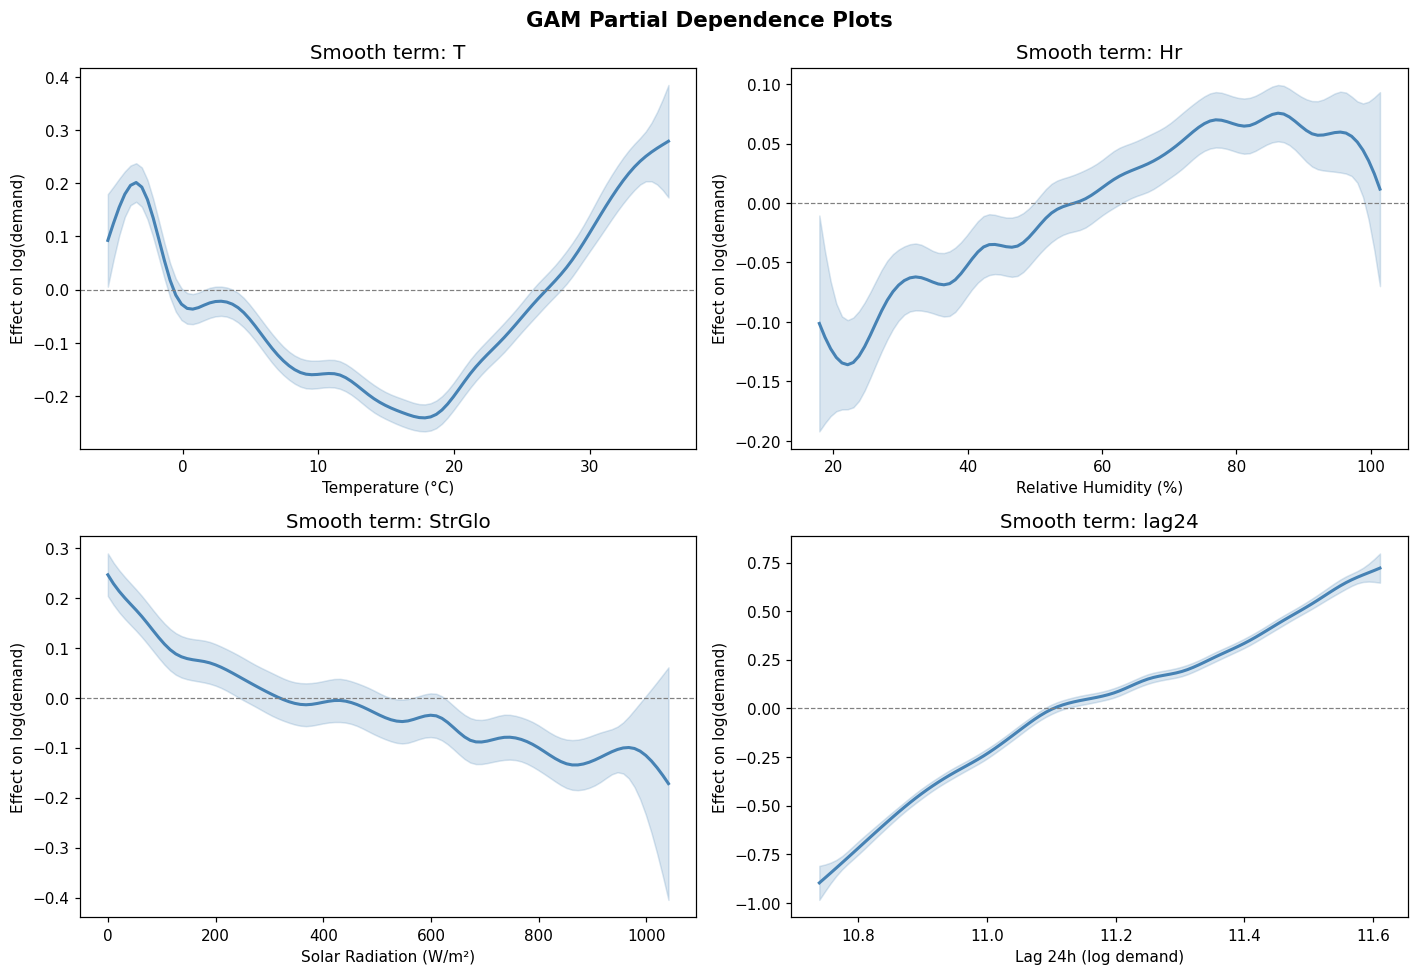

In [54]:
# --- 1. Evaluate Model on Test Set ---
fitted_test_scaled = gam.predict(X_test_scaled)
r2_test = r2_score(y_test_scaled, fitted_test_scaled)

print(f'R² (test): {r2_test:.4f}')

pdp_terms = [
    (6, 'T',        'Temperature (°C)'),
    (7, 'Hr',       'Relative Humidity (%)'),
    (8, 'StrGlo',   'Solar Radiation (W/m²)'),
    (9, 'lag24',     'Lag 24h (log demand)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (col_index, name, label) in zip(axes.flat, pdp_terms):

    # Ask the model for the scaled X grid (the Z-scores)
    grid_scaled = gam.generate_X_grid(term=col_index)

    # Get the Y-axis effect and the confidence bands
    y_effect, confidence_bands = gam.partial_dependence(term=col_index, X=grid_scaled, width=0.95)

    # Convert the scaled grid back into real numbers (Celsius)
    grid_real = scaler_X.inverse_transform(grid_scaled)

    # Extract specific column we need for the X-axis
    x_real = grid_real[:, col_index]

    # Plot the line and the shaded confidence area
    ax.plot(x_real, y_effect, color='steelblue', lw=2)

    ax.fill_between(x_real, confidence_bands[:, 0], confidence_bands[:, 1],
                    alpha=0.2, color='steelblue')

    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_xlabel(label)
    ax.set_ylabel('Effect on log(demand)')
    ax.set_title(f'Smooth term: {name}')

fig.suptitle('GAM Partial Dependence Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/05_gam/05_13_gam_pdp.png', bbox_inches='tight')
plt.show()

#### STEP 6: DIAGNOSTICS (check if it's valid)

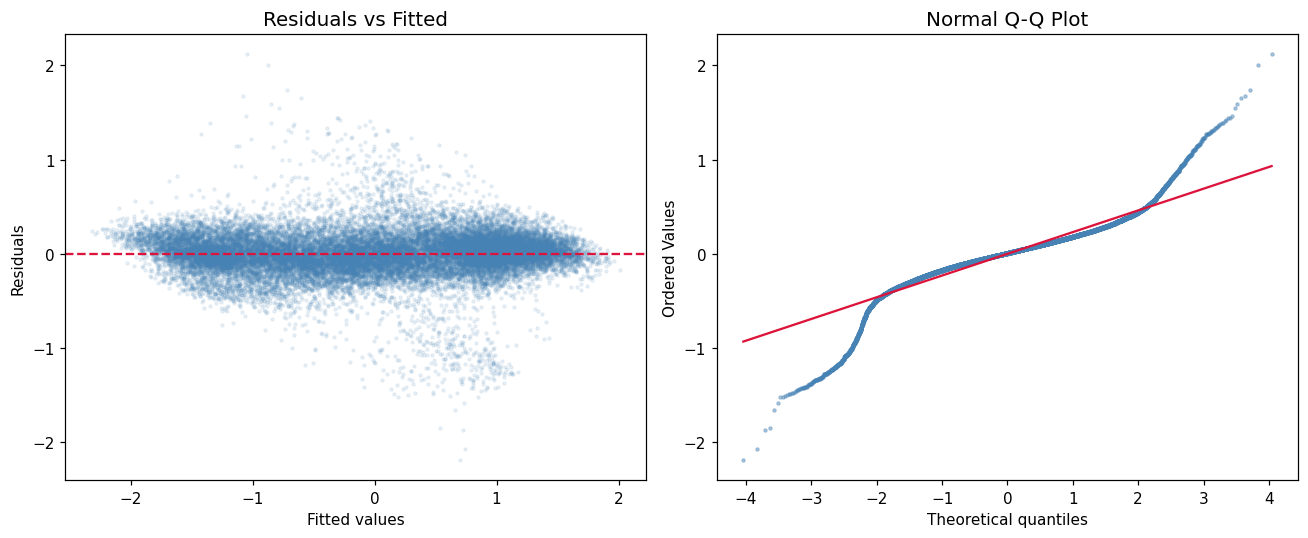

In [55]:
fitted = gam.predict(X_train_scaled)
residuals = y_train_scaled - fitted

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted, residuals, alpha=0.1, s=4, color='steelblue')
axes[0].axhline(0, color='crimson', lw=1.5, ls='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q Plot')
axes[1].get_lines()[0].set(markersize=2, alpha=0.4, color='steelblue')
axes[1].get_lines()[1].set(color='crimson')

plt.tight_layout()
plt.savefig('../outputs/figures/05_gam/05_14_gam_diagnostics.png', bbox_inches='tight')
plt.show()

#### STEP 7: TEST SET PREDICTIONS & EVALUATION

In [56]:
y_pred_log_scaled = gam.predict(X_test_scaled)
y_pred_log = scaler_y.inverse_transform(y_pred_log_scaled.reshape(-1, 1)).ravel()
y_pred     = np.exp(y_pred_log)
y_actual   = np.exp(y_test)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)

print(f'RMSE : {rmse:,.1f} kW  ({rmse / y_actual.mean() * 100:.1f}% of mean)')
print(f'MAE  : {mae:,.1f} kW  ({mae  / y_actual.mean() * 100:.1f}% of mean)')
print(f'Mean demand: {y_actual.mean():,.1f} kW')

RMSE : 3,717.8 kW  (5.0% of mean)
MAE  : 2,513.4 kW  (3.4% of mean)
Mean demand: 73,971.1 kW


#### STEP 8: VISUALIZATION

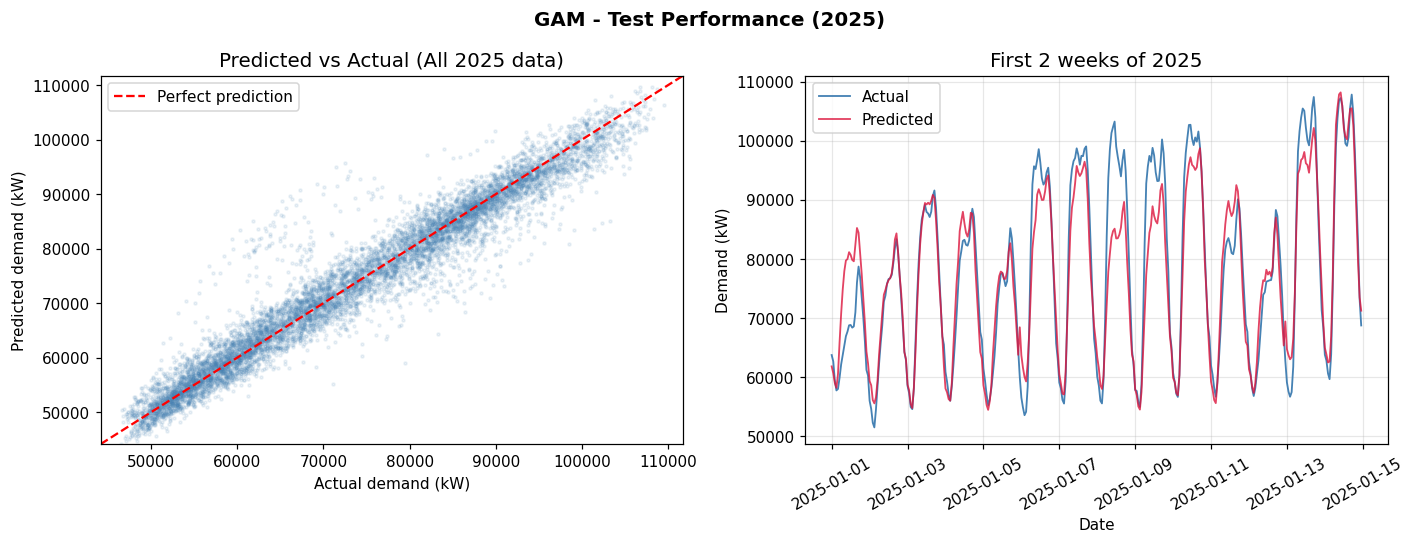

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: predicted vs actual
lim = [y_actual.min() * 0.95, y_actual.max() * 1.02]
axes[0].scatter(y_actual, y_pred, alpha=0.1, s=4, color='steelblue')
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual demand (kW)')
axes[0].set_ylabel('Predicted demand (kW)')
axes[0].set_title('Predicted vs Actual (All 2025 data)')
axes[0].legend()

#First 2 weeks of 2025, same window as the LM for visual comparison (scaled)
two_weeks = test.iloc[:24*14]
y_tw_actual = np.exp(two_weeks['demand_log'].values)

# Scale the two-week test data properly
two_weeks_scaled = scaler_X.transform(two_weeks[FEATURES].values)
y_tw_pred_scaled = gam.predict(two_weeks_scaled)
y_tw_pred_log = scaler_y.inverse_transform(y_tw_pred_scaled.reshape(-1, 1)).ravel()
y_tw_pred = np.exp(y_tw_pred_log)

axes[1].plot(two_weeks.index, y_tw_actual, lw=1.2, label='Actual', color='steelblue')
axes[1].plot(two_weeks.index, y_tw_pred, lw=1.2, label='Predicted', color='crimson', alpha=0.8)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Demand (kW)')
axes[1].set_title('First 2 weeks of 2025')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3)

fig.suptitle('GAM - Test Performance (2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/05_gam/05_15_gam_pred_vs_actual.png', bbox_inches='tight')
plt.show()

#### STEP 9: SAVE METRICS AND MODEL COMPARISON

#### 6. Comparison with LM

T has a non-linear effect: steep drop at low temperatures, flatter at high ones.
The LM can only approximate this with a linear term. Same pattern for StrGlo.
Lower RMSE/MAE vs the LM would mean the splines are actually helping.

In [58]:
new_row = pd.DataFrame([{
    'model':    'GAM',
    'rmse':     round(rmse, 1),
    'mae':      round(mae, 1),
    'r2_train': round(gam.statistics_['pseudo_r2']['explained_deviance'], 4),
    'r2_test':  round(r2_test, 4),
    'auc':      np.nan
}])

out = '../outputs/model_comparison.csv'
if os.path.exists(out):
    existing = pd.read_csv(out)
    existing = existing[existing['model'] != 'GAM']
    new_row = pd.concat([existing, new_row], ignore_index=True)

new_row.to_csv(out, index=False)
print(new_row.to_string())

          model      rmse       mae  r2_train     auc  r2_test
0            LM  7623.700  6125.800    0.7855     NaN      NaN
1   GLM_Poisson     2.575     1.441    0.6887     NaN      NaN
2  GLM_Binomial       NaN       NaN    0.5254  0.9593      NaN
3   NN (128,64)  2660.600  2038.200    0.9710     NaN      NaN
4           SVM   881.000   653.700    0.9967     NaN      NaN
5           GAM  3717.800  2513.400    0.9404     NaN   0.9427
